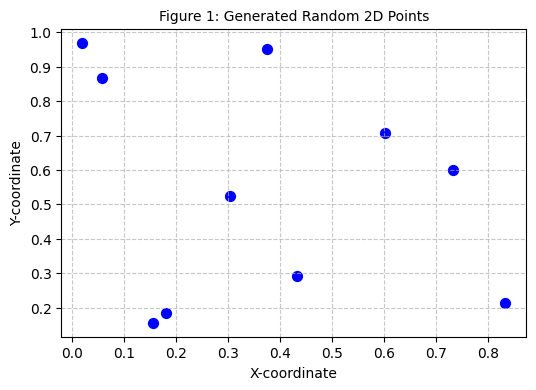

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import timeit

# Set a fixed seed for reproducibility
np.random.seed(42)

# Generate 10 random 2D points
N = 10
X = np.random.rand(N, 2)

# Plot the points
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c='blue', s=50)
plt.title('Figure 1: Generated Random 2D Points', fontsize=10)
plt.xlabel('X-coordinate', fontsize=10)
plt.ylabel('Y-coordinate', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [ ]:
# (a) The coordinate differences
# X[:, np.newaxis, :] reshapes X from (10, 2) to (10, 1, 2)
# X[np.newaxis, :, :] reshapes X from (10, 2) to (1, 10, 2)
# Broadcasting subtraction gives a (10, 10, 2) array of coordinate differences
differences = X[:, np.newaxis, :] - X[np.newaxis, :, :]
print("Shape of coordinate differences:", differences.shape)

# (b) The squared differences
sq_differences = differences ** 2
print("Shape of squared differences:", sq_differences.shape)

# (c) The summed squared distances
# Summing along the last axis (axis=-1) which represents the 2 dimensions (x, y)
dist_sq = sq_differences.sum(axis=-1)
print("Shape of summed squared distances:", dist_sq.shape)

# Single line computation as requested
dist_sq_single_line = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=-1)


Shape of coordinate differences: (10, 10, 2)
Shape of squared differences: (10, 10, 2)
Shape of summed squared distances: (10, 10)


In [ ]:
# Check the diagonal
diagonal = dist_sq.diagonal()
print("Diagonal of the distance matrix:\n", diagonal)


Diagonal of the distance matrix:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
# Get the index ordering of neighbors for each point
nearest_partition = np.argsort(dist_sq, axis=1)
print("First column of argsort result:\n", nearest_partition[:, 0])


First column of argsort result:
 [0 1 2 3 4 5 6 7 8 9]


In [ ]:
K = 2
# We use K+1 because the point itself is included as the nearest neighbor (distance 0)
k_nearest_indices = np.argpartition(dist_sq, K + 1, axis=1)
# We only care about the first K+1 indices
k_nearest_indices = k_nearest_indices[:, :K + 1]
print("Indices of the K+1 nearest neighbors (including self):\n", k_nearest_indices)


Indices of the K+1 nearest neighbors (including self):
 [[0 3 4]
 [1 4 6]
 [2 7 9]
 [3 5 0]
 [4 1 0]
 [5 3 0]
 [6 1 9]
 [7 2 9]
 [8 9 4]
 [9 8 7]]


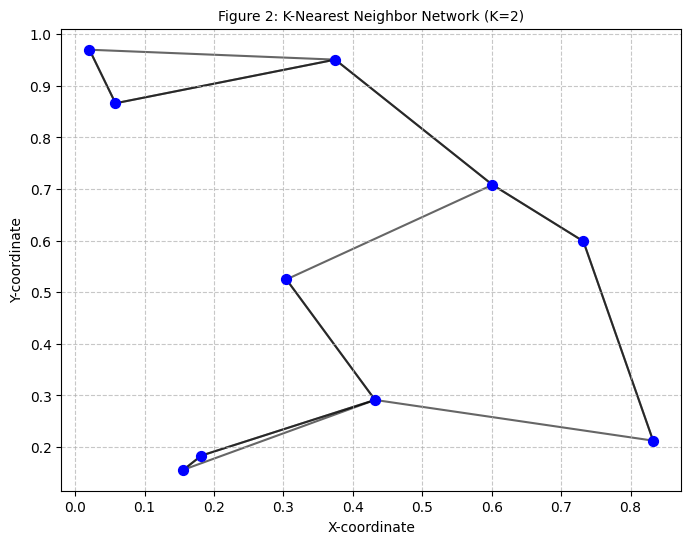

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', s=50, zorder=3)

# Draw lines from each point to its K nearest neighbors
for i in range(X.shape[0]):
    # The first element in k_nearest_indices[i] might be 'i' itself,
    # but the first K+1 elements are the closest points including 'i'.
    for j in k_nearest_indices[i]:
        if i != j:  # Don't draw a line to itself
            # Plot a line connecting point i and point j
            plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], 'k-', zorder=1, alpha=0.6)

plt.title('Figure 2: K-Nearest Neighbor Network (K=2)', fontsize=10)
plt.xlabel('X-coordinate', fontsize=10)
plt.ylabel('Y-coordinate', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



In [ ]:
def knn_loops(X, k=2):
    num_points = X.shape[0]
    neighbors = np.zeros((num_points, k + 1), dtype=int)
    for i in range(num_points):
        distances = []
        for j in range(num_points):
            # Explicit distance calculation
            dist = (X[i, 0] - X[j, 0])**2 + (X[i, 1] - X[j, 1])**2
            distances.append(dist)
        # Sort and get indices
        sorted_indices = sorted(range(len(distances)), key=lambda k: distances[k])
        neighbors[i] = sorted_indices[:k+1]
    return neighbors


In [ ]:
def knn_vectorized(X, k=2):
    dist_sq = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=-1)
    return np.argpartition(dist_sq, k + 1, axis=1)[:, :k + 1]

N_values = [100, 1000, 5000]
print(f"{'N':<10} | {'Loop-based Time':<20} | {'Vectorized Time':<20}")
print("-" * 55)

for n in N_values:
    X_test = np.random.rand(n, 2)

    # Timing loop-based
    start_loop = timeit.default_timer()
    knn_loops(X_test)
    time_loop = timeit.default_timer() - start_loop

    # Timing vectorized
    start_vec = timeit.default_timer()
    knn_vectorized(X_test)
    time_vec = timeit.default_timer() - start_vec

    print(f"{n:<10} | {time_loop:.6f} seconds      | {time_vec:.6f} seconds")


N          | Loop-based Time      | Vectorized Time     
-------------------------------------------------------
100        | 0.015617 seconds      | 0.001089 seconds
1000       | 1.588903 seconds      | 0.069369 seconds
5000       | 48.430611 seconds      | 1.401598 seconds


In [ ]:
from sklearn.neighbors import KDTree

N_bonus = 1000
X_bonus = np.random.rand(N_bonus, 2)
K = 2

# Time NumPy Vectorized version
start_vec = timeit.default_timer()
dist_sq = np.sum((X_bonus[:, np.newaxis, :] - X_bonus[np.newaxis, :, :]) ** 2, axis=-1)
numpy_neighbors = np.argpartition(dist_sq, K + 1, axis=1)[:, :K + 1]
time_vec = timeit.default_timer() - start_vec

# Time Scikit-Learn KDTree
start_kd = timeit.default_timer()
# Building the tree is O(N log N)
tree = KDTree(X_bonus)
# Querying is also O(N log N) for all N points
dist, kd_neighbors = tree.query(X_bonus, k=K + 1)
time_kd = timeit.default_timer() - start_kd

print(f"NumPy Vectorized Time for N=1000: {time_vec:.6f} seconds")
print(f"Scikit-Learn KDTree Time for N=1000: {time_kd:.6f} seconds")


NumPy Vectorized Time for N=1000: 0.052834 seconds
Scikit-Learn KDTree Time for N=1000: 0.004926 seconds
